In [1]:
import sys
import os
from datetime import datetime

import numpy as np

import matplotlib
matplotlib.rcParams['text.usetex'] = True
import matplotlib.pyplot as plt

from scipy.linalg import sqrtm
from scipy.linalg import inv

from joblib import Parallel, delayed

sys.path.insert(0, '../')
from codes.Quantum import *

from codes.Quantum import *
from codes.CSPSA import CSPSA
from ClassicalShadows import EnchancedShadowTomography

In [7]:
Rho = None
enhanced_shadows = None


gains = [3, 0, 0.1, 0.602, 0.101]
cspsa = CSPSA(gains=gains, minimize=False)


def complex2unitary( Z ):
    """
    Proyecta una matriz compleja arbitraria Z al grupo unitario U(4)
    mediante descomposición polar, U = Z (Z^dagger Z)^{-1/2}.
    """
    if Z.ndim == 3:
        for k, z in enumerate(Z):
            Z[k] = z @ inv( sqrtm( z.T.conj()@z ) )
    else:
        Z = Z @ inv( sqrtm( Z.T.conj()@Z ) )
    return Z


def random_unitary( dim, num=1 ):
    """
    Genera 'num' matrices unitarias aleatorias de dimensión 'dim'.
    """
    Z = np.random.randn( num, dim, dim ) \
        + 1j*np.random.randn( num, dim, dim )
    return complex2unitary( Z ).squeeze()


def maximally_entangled_state():
    """
    Estado singlete de dos qubits, (|01> - |10>)/sqrt(2), sin parámetro libre.
    """
    psi = np.array([0, 1, -1, 0]) / np.sqrt(2)
    return np.outer(psi, psi.conj())


def schmidt_state(a):
    """
    Estado puro de dos qubits en descomposición de Schmidt con parámetro
    a en [0, 0.5]. a = 0.5 recupera el estado maximamente entrelazado,
    a = 0 recupera el estado producto |00>.
    """
    psi = np.sqrt(1 - a) * np.array([1, 0, 0, 0]) \
        + np.sqrt(a) * np.array([0, 0, 0, 1])
    return np.outer(psi, psi.conj())


def werner_state(p):
    """
    Estado de Werner de dos qubits, mezcla convexa entre el estado singlete
    y el estado maximamente mixto, con parámetro de pureza p en [0, 1].
    p = 1 recupera el estado singlete puro, p = 0 el estado maximamente mixto.
    """
    rho_singlet = maximally_entangled_state()
    return p * rho_singlet + (1 - p) * np.eye(4) / 4


def build_network_state(rho_X, rho_Y, rho_Z):
    """
    Construye la matriz densidad conjunta de los seis qubits de la red
    triangular a partir de los estados de dos qubits (rho_X, rho_Y, rho_Z)
    distribuidos de forma independiente por las tres fuentes, reordenando
    los qubits para que cada detector reciba el par que le corresponde.
    """
    Rho = np.kron(np.kron(rho_X, rho_Y), rho_Z)
    permutation = [5, 0, 2, 1, 4, 3]
    order = permutation + [6 + q for q in permutation]
    Rho = Rho.reshape(12 * [2]).transpose(order).reshape(64, 64)
    return Rho


def create_shadow(Rho, N):
    """
    Entrena una sombra clasica de tamaño N a partir del estado Rho, y
    construye a partir de ella la reconstruccion Rho_hat que se usa como
    estado de referencia sigma en el estimador con variable de control.
    """
    shadow = EnchancedShadowTomography(6, N)
    shadow.train_shadows(Rho)
    Rho_hat = shadow.estimate_density_matrix()
    shadow.enhance_shadow(Rho_hat)
    return shadow, Rho_hat


def out_fun( Z, Rho=Rho ):
    """
    Evalua el funcional wagon-wheel de forma exacta, tal como se calcula
    en cspsa_triangle_shadows.ipynb, sin ninguna modificación en el cálculo.
    """
    Z  = np.array(Z)
    Z = complex2unitary( Z )
    Measures = triple_kron( Z[0], Z[1], Z[2] ) 
    probs  = np.sum( Measures.conj() * ( Rho @ Measures ), 
                        axis=0 ).reshape(6*[2]).real 
    probs_albl = np.sum( probs, axis=(1,3,4,5) )
    probs_alblclcr = np.sum( probs, axis=(1,3) )
    probs_clcr = np.sum( probs, axis=(0,1,2,3) )
    inequality = (-probs_albl[1,0] 
                +probs_alblclcr[1,0,1,0] 
                -probs_albl[0,1] * probs_clcr[1,0] 
                -probs_clcr[0,0] * probs_clcr[1,1] 
                -probs_clcr[0,1] * probs[1,0,0,1,1,0]
                -probs_clcr[0,1] * probs[1,1,0,0,1,0]
                +probs_clcr[0,0] * probs[1,0,1,1,1,1]
                +probs_clcr[0,0] * probs[1,1,1,0,1,1]
                +probs_clcr[1,0] * probs[0,0,1,0,0,1]
                +probs_clcr[1,0] * probs[0,1,1,1,0,1]
                +probs_clcr[1,1] * probs[0,0,0,0,0,0]
                +probs_clcr[1,1] * probs[0,1,0,1,0,0]
                )
    return inequality 


def obj_fun( Z, enhanced_shadows=enhanced_shadows ):
    """
    Evalua el funcional wagon-wheel estimando cada termino con Classical
    Shadows en su version estandar (sin variable de control). Cálculo
    idéntico al de cspsa_triangle_shadows.ipynb.
    """
    Z  = np.array(Z)
    Z = complex2unitary( Z )
    Z0 = Z[0]
    Z1 = Z[1]
    Z2 = Z[2]
    Pi = [  np.outer(Z0[:,2],Z0[:,2].conj())+np.outer( Z0[:,3],Z0[:,3].conj() ),
            np.outer(Z1[:,0],Z1[:,0].conj())+np.outer( Z1[:,1],Z1[:,1].conj() ) ,
            np.eye(4),
                ]
    prob_albl_10 = enhanced_shadows.estimate_global_observable( 
                        triple_kron( Pi[0], Pi[1], Pi[2] ) )
    Pi = [  np.outer(Z0[:,0],Z0[:,0].conj()) +np.outer( Z0[:,1],Z0[:,1].conj() ),
            np.outer(Z1[:,2],Z1[:,2].conj()) +np.outer( Z1[:,3],Z1[:,3].conj() ) ,
            np.eye(4),
                ]
    prob_albl_01 = enhanced_shadows.estimate_global_observable( 
                        triple_kron( Pi[0], Pi[1], Pi[2] ) )
    Pi = [  np.outer(Z0[:,2],Z0[:,2].conj()) +np.outer( Z0[:,3],Z0[:,3].conj() ),
            np.outer(Z1[:,0],Z1[:,0].conj()) +np.outer( Z1[:,1],Z1[:,1].conj() ) ,
            np.outer(Z2[:,2],Z2[:,2].conj()),
                ]
    probs_alblclcr_1010 = enhanced_shadows.estimate_global_observable( 
                        triple_kron( Pi[0], Pi[1], Pi[2] ) )
    probs_clcr = np.zeros(4)
    for j in range(4):
            Pi = [  np.eye(4),
                    np.eye(4),
                    np.outer(Z2[:,j],Z2[:,j].conj()),
                        ]
            probs_clcr[j] = enhanced_shadows.estimate_global_observable( 
                                triple_kron( Pi[0], Pi[1], Pi[2] ) )
    probs_clcr = probs_clcr.reshape(2,2)
    probs = np.zeros((4,4,4))
    index = [ [2,1,2], [3,0,2], [2,3,3], [3,2,3], [0,2,1], [1,3,1],[0,0,0],[1,1,0]  ]
    for i,j,k in index:
        Pi = [  np.outer(Z0[:,i],Z0[:,i].conj()),
            np.outer(Z1[:,j],Z1[:,j].conj()) ,
            np.outer(Z2[:,k],Z2[:,k].conj()),
                ]
        probs[i,j,k] = enhanced_shadows.estimate_global_observable( 
                            triple_kron( Pi[0], Pi[1], Pi[2] ) )
    probs = probs.reshape(2,2,2,2,2,2)
    inequality = (-prob_albl_10
                +probs_alblclcr_1010
                -prob_albl_01 * probs_clcr[1,0] 
                -probs_clcr[0,0] * probs_clcr[1,1] 
                -probs_clcr[0,1] * probs[1,0,0,1,1,0]
                -probs_clcr[0,1] * probs[1,1,0,0,1,0]
                +probs_clcr[0,0] * probs[1,0,1,1,1,1]
                +probs_clcr[0,0] * probs[1,1,1,0,1,1]
                +probs_clcr[1,0] * probs[0,0,1,0,0,1]
                +probs_clcr[1,0] * probs[0,1,1,1,0,1]
                +probs_clcr[1,1] * probs[0,0,0,0,0,0]
                +probs_clcr[1,1] * probs[0,1,0,1,0,0]
                )
    return inequality 


def obj_fun_enhanced( Z, enhanced_shadows=enhanced_shadows):
    """
    Igual a obj_fun, pero estimando cada termino con la correccion de
    variable de control (estimate_global_observable_enhanced). Cálculo
    idéntico al de cspsa_triangle_shadows.ipynb.
    """
    Z  = np.array(Z)
    Z = complex2unitary( Z )
    Z0 = Z[0]
    Z1 = Z[1]
    Z2 = Z[2]
    Pi = [  np.outer(Z0[:,2],Z0[:,2].conj())+np.outer( Z0[:,3],Z0[:,3].conj() ),
            np.outer(Z1[:,0],Z1[:,0].conj())+np.outer( Z1[:,1],Z1[:,1].conj() ) ,
            np.eye(4),
                ]
    prob_albl_10 = enhanced_shadows.estimate_global_observable_enhanced( 
                        triple_kron( Pi[0], Pi[1], Pi[2] ) )
    Pi = [  np.outer(Z0[:,0],Z0[:,0].conj()) +np.outer( Z0[:,1],Z0[:,1].conj() ),
            np.outer(Z1[:,2],Z1[:,2].conj()) +np.outer( Z1[:,3],Z1[:,3].conj() ) ,
            np.eye(4),
                ]
    prob_albl_01 = enhanced_shadows.estimate_global_observable_enhanced( 
                        triple_kron( Pi[0], Pi[1], Pi[2] ) )
    Pi = [  np.outer(Z0[:,2],Z0[:,2].conj()) +np.outer( Z0[:,3],Z0[:,3].conj() ),
            np.outer(Z1[:,0],Z1[:,0].conj()) +np.outer( Z1[:,1],Z1[:,1].conj() ) ,
            np.outer(Z2[:,2],Z2[:,2].conj()),
                ]
    probs_alblclcr_1010 = enhanced_shadows.estimate_global_observable_enhanced( 
                        triple_kron( Pi[0], Pi[1], Pi[2] ) )
    probs_clcr = np.zeros(4)
    for j in range(4):
            Pi = [  np.eye(4),
                    np.eye(4),
                    np.outer(Z2[:,j],Z2[:,j].conj()),
                        ]
            probs_clcr[j] = enhanced_shadows.estimate_global_observable_enhanced( 
                                triple_kron( Pi[0], Pi[1], Pi[2] ) )
    probs_clcr = probs_clcr.reshape(2,2)
    probs = np.zeros((4,4,4))
    index = [ [2,1,2], [3,0,2], [2,3,3], [3,2,3], [0,2,1], [1,3,1],[0,0,0],[1,1,0]  ]
    for i,j,k in index:
        Pi = [  np.outer(Z0[:,i],Z0[:,i].conj()),
            np.outer(Z1[:,j],Z1[:,j].conj()) ,
            np.outer(Z2[:,k],Z2[:,k].conj()),
                ]
        probs[i,j,k] = enhanced_shadows.estimate_global_observable_enhanced( 
                            triple_kron( Pi[0], Pi[1], Pi[2] ) )
    probs = probs.reshape(2,2,2,2,2,2)
    inequality = (-prob_albl_10
                +probs_alblclcr_1010
                -prob_albl_01 * probs_clcr[1,0] 
                -probs_clcr[0,0] * probs_clcr[1,1] 
                -probs_clcr[0,1] * probs[1,0,0,1,1,0]
                -probs_clcr[0,1] * probs[1,1,0,0,1,0]
                +probs_clcr[0,0] * probs[1,0,1,1,1,1]
                +probs_clcr[0,0] * probs[1,1,1,0,1,1]
                +probs_clcr[1,0] * probs[0,0,1,0,0,1]
                +probs_clcr[1,0] * probs[0,1,1,1,0,1]
                +probs_clcr[1,1] * probs[0,0,0,0,0,0]
                +probs_clcr[1,1] * probs[0,1,0,1,0,0]
                )
    return inequality

from joblib import Parallel, delayed

def run_simulation(Rho, N_rep, max_iter, N_shadow, nombre_archivo,
                    carpeta=".", n_jobs=-1):
    """
    Corre el protocolo completo de optimizacion (Tomo, Shadow, EnhShadow)
    sobre el estado Rho entregado, durante N_rep repeticiones independientes
    de max_iter iteraciones cada una, reentrenando una sombra de N_shadow
    mediciones en cada repeticion. Las repeticiones se paralelizan con
    joblib, y cada una reinicializa su semilla aleatoria para asegurar
    independencia entre procesos.

    Guarda en carpeta/nombre_archivo, imitando el formato de
    Tesis_Schmidt.ipynb, el arreglo crudo de cada nivel de evaluacion
    (Out1, Out2, Out3) junto con su mean, median, q1 y q3 por iteracion,
    mas metadatos (N_rep, max_iter, N_shadow).
    """
    def run_one(idx):
        np.random.seed()
        print(idx)

        enhanced_shadows, Rho_hat = create_shadow(Rho, N_shadow)

        obj_fun_tomo = lambda Z: out_fun(Z, Rho_hat)
        obj_fun_shad = lambda Z: obj_fun(Z, enhanced_shadows)
        obj_fun_enha = lambda Z: obj_fun_enhanced(Z, enhanced_shadows)

        Z_in3 = np.array([np.kron(random_unitary(2), random_unitary(2)) for _ in range(3)])

        results1 = cspsa.minimize(obj_fun_tomo, Z_in3, max_iter,
                                   postprocessing=complex2unitary,
                                   output_function=obj_fun_tomo)
        results2 = cspsa.minimize(obj_fun_shad, Z_in3, max_iter,
                                   postprocessing=complex2unitary,
                                   output_function=obj_fun_shad)
        results3 = cspsa.minimize(obj_fun_enha, Z_in3, max_iter,
                                   postprocessing=complex2unitary,
                                   output_function=obj_fun_enha)

        return results1.fun, results2.fun, results3.fun

    resultados = Parallel(n_jobs=n_jobs)(
        delayed(run_one)(idx) for idx in range(N_rep)
    )
    resultados = np.array(resultados)

    Out1 = resultados[:, 0]
    Out2 = resultados[:, 1]
    Out3 = resultados[:, 2]

    os.makedirs(carpeta, exist_ok=True)
    ruta = os.path.join(carpeta, nombre_archivo)

    np.savez(ruta,
             Out1=Out1, Out2=Out2, Out3=Out3,
             mean1=Out1.mean(axis=0), median1=np.median(Out1, axis=0),
             q1_1=np.percentile(Out1, 25, axis=0), q3_1=np.percentile(Out1, 75, axis=0),
             mean2=Out2.mean(axis=0), median2=np.median(Out2, axis=0),
             q1_2=np.percentile(Out2, 25, axis=0), q3_2=np.percentile(Out2, 75, axis=0),
             mean3=Out3.mean(axis=0), median3=np.median(Out3, axis=0),
             q1_3=np.percentile(Out3, 25, axis=0), q3_3=np.percentile(Out3, 75, axis=0),
             N_rep=N_rep, max_iter=max_iter, N_shadow=N_shadow)

    print(f"  Guardado: {ruta}")

    return Out1, Out2, Out3

In [3]:
def cargar_npz(carpeta, nombre_archivo):
    """
    Carga el archivo .npz correspondiente a una simulacion, ubicado en
    carpeta/nombre_archivo.
    """
    return np.load(os.path.join(carpeta, nombre_archivo))

# Simulación 01

**Carpeta de datos:** `Simulacion_01`

**Parámetros:**

| Parámetro | Valor |
|---|---|
| Estado (tres fuentes) | Estado maximalmente entrelazado, singlete $(\lvert 01\rangle-\lvert 10\rangle)/\sqrt{2}$, sin parámetro libre |
| $N$ (mediciones por sombra) | $10000$, sombra reentrenada en cada repetición |
| `max_rep` | 100 |
| `max_iter` | 1000 |
| `gains` | `[3, 0, 0.1, 0.602, 0.101]` |
| Optimizador | CSPSA (`minimize=False`, maximización) |

**Descripción:** primer escenario de la serie, usado como caso base de
referencia, en el que las tres fuentes de la red triangular distribuyen
el mismo estado maximalmente entrelazado, sin parámetro libre. Se
comparan tres niveles de evaluación del funcional wagon-wheel a lo largo
de las iteraciones, la reconstrucción tomográfica obtenida a partir de
la sombra (`Out1`), la estimación directa con Classical Shadows en su
versión estándar (`Out2`), y la variante con corrección de variable de
control (`Out3`), las tres calculadas sobre la misma sombra entrenada en
cada repetición.

**Archivos generados:** `Simulacion_01/Sim01.npz`, con el arreglo crudo
de cada nivel (`Out1`, `Out2`, `Out3`, de tamaño `max_rep` x `max_iter`)
junto con `mean`, `median`, `q1` y `q3` por iteración para cada uno
(`mean1`/`median1`/`q1_1`/`q3_1`, y así para 2 y 3).

In [ ]:
Rho_max = build_network_state(*3 * [maximally_entangled_state()])

#Out1, Out2, Out3 = run_simulation(
#    Rho_max,
#    N_rep=100,
#    max_iter=1000,
#    N_shadow=100000,
#    nombre_archivo="Sim01.npz",
#    carpeta="Simulacion_01"w
#)

## Gráfico Simulación 01 — Convergencia de la mediana

Muestra la mediana de $I_{\rm w-w}$ a lo largo de las `max_iter`
iteraciones para los tres niveles de evaluación (Tomo, Shadow,
EnhShadow), junto con la cota clásica ($I_{\rm w-w}=0$) y el máximo
cuántico $(\sqrt{2}-1)/16$, para el estado maximalmente entrelazado.

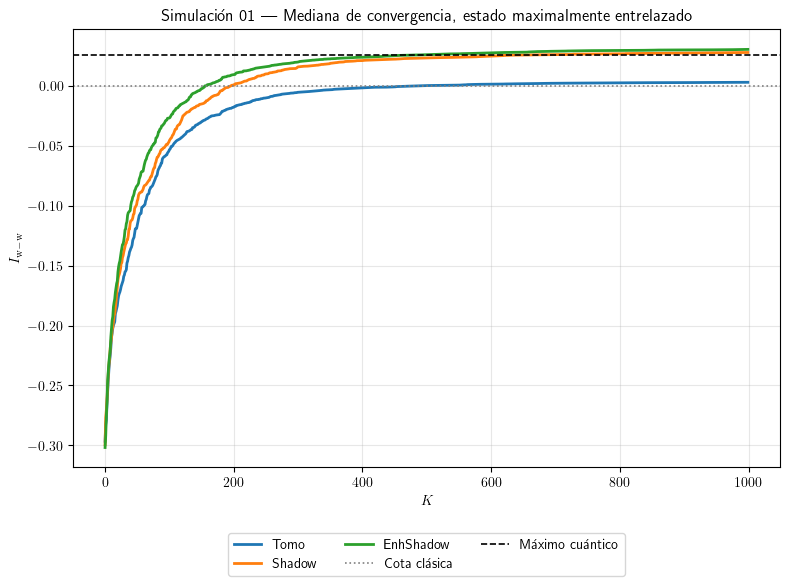

In [4]:
Data = cargar_npz("Simulacion_01", "Sim01.npz")
it = np.arange(len(Data['median1']))
valor_cuantico = (np.sqrt(2) - 1) / 16

plt.figure(figsize=(8, 6))
plt.plot(it, Data['median1'], label="Tomo", linewidth=2)
plt.plot(it, Data['median2'], label="Shadow", linewidth=2)
plt.plot(it, Data['median3'], label="EnhShadow", linewidth=2)
plt.axhline(0, color='gray', linestyle=':', linewidth=1.2, label="Cota clásica")
plt.axhline(valor_cuantico, color='black', linestyle='--', linewidth=1.2, label="Máximo cuántico")
plt.xlabel(r"$K$")
plt.ylabel(r"$I_{\rm w-w}$")
plt.title(r"Simulación 01 --- Mediana de convergencia, estado maximalmente entrelazado")
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=3, borderaxespad=0)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("Simulacion_01/Sim01_3maxent_med.pdf")
plt.savefig("Simulacion_01/Sim01_3maxent_med.png", dpi=600)
plt.show()

## Función `graficar_convergencia_grid`

Busca en disco los archivos `{prefijo}_{parametro}*.npz`, y arma un panel
de subgráficos, uno por valor del parámetro, cada uno mostrando la
convergencia de la mediana para los tres niveles de evaluación, junto
con la cota clásica y el máximo cuántico.

In [12]:
def graficar_convergencia_grid(prefijo, carpeta, parametro_nombre,
                                parametro_simbolo, titulo, nombre_salida):
    """
    Busca en disco carpeta/prefijo_{parametro}*.npz y arma un panel de
    subgraficos, uno por valor del parametro, mostrando la convergencia
    de la mediana para los tres niveles de evaluacion (Tomo, Shadow,
    EnhShadow), junto con la cota clasica y el maximo cuantico.
    """
    patron = os.path.join(carpeta, f"{prefijo}_{parametro_nombre}*.npz")
    archivos = sorted(glob.glob(patron))

    datos = []
    for ruta in archivos:
        nombre = os.path.basename(ruta)
        match = re.search(rf"{parametro_nombre}([0-9.]+)\.npz", nombre)
        valor = float(match.group(1))
        Data = np.load(ruta)
        datos.append((valor, Data))
    datos.sort(key=lambda x: x[0])

    n = len(datos)
    ncols = min(3, n)
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(4.2 * ncols, 3.2 * nrows),
                              sharex=True, sharey=True)
    axes = np.array(axes).reshape(-1)
    valor_cuantico = (np.sqrt(2) - 1) / 16

    for ax, (valor, Data) in zip(axes, datos):
        it = np.arange(len(Data['median1']))
        ax.plot(it, Data['median1'], label="Tomo")
        ax.plot(it, Data['median2'], label="Shadow")
        ax.plot(it, Data['median3'], label="EnhShadow")
        ax.axhline(0, linestyle=':', color='gray')
        ax.axhline(valor_cuantico, linestyle='--', color='black')
        ax.set_title(rf"${parametro_simbolo}={valor:.2f}$")

    for ax in axes[n:]:
        ax.axis('off')

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='lower center', ncol=5)
    fig.suptitle(titulo)
    fig.tight_layout(rect=[0, 0.05, 1, 0.96])
    fig.savefig(nombre_salida)
    plt.show()

    return n

# Simulación 02

**Carpeta de datos:** `Simulacion_02`

**Parámetros:**

| Parámetro | Valor |
|---|---|
| Estado (tres fuentes) | Descomposición de Schmidt, $\sqrt{1-a}\,\lvert 00\rangle+\sqrt{a}\,\lvert 11\rangle$, mismo $a$ en las tres fuentes |
| $N$ (mediciones por sombra) | $10000$, sombra reentrenada en cada repetición |
| `max_rep` | 100 |
| `max_iter` | 1000 |
| `gains` | `[3, 0, 0.1, 0.602, 0.101]` |
| Optimizador | CSPSA (`minimize=False`, maximización) |

**Descripción:** segundo escenario de la serie, en el que las tres
fuentes de la red triangular distribuyen el mismo estado con
descomposición de Schmidt. Se corre en dos grillas distintas del
parámetro $a$, identificadas como Sim02_01 y Sim02_02, para explorar
primero el rango completo y luego refinar la zona cercana al estado
maximalmente entrelazado en esta base.

**Sim02_01, grilla completa:** $a \in \{0.0,\ 0.1,\ 0.2,\ 0.3,\ 0.4,\ 0.5\}$,
paso $0.1$, desde el estado producto hasta el estado maximalmente
entrelazado.

**Sim02_02, grilla refinada:** $a \in \{0.30,\ 0.35,\ 0.40,\ 0.45,\ 0.50\}$,
paso $0.05$, restringida a la región $[0.3, 0.5]$ donde se concentra el
comportamiento más relevante de $I_{\rm w-w}$.

**Archivos generados:** `Simulacion_02/Sim02_01_a{valor}.npz` y
`Simulacion_02/Sim02_02_a{valor}.npz`, uno por cada valor de $a$ en cada
grilla, cada uno con el arreglo crudo de cada nivel (`Out1`, `Out2`,
`Out3`) junto con `mean`, `median`, `q1` y `q3` por iteración para cada
uno, igual que en Simulación 01.

In [14]:
def run_schmidt_grid(valores_a, prefijo, carpeta="Simulacion_02",
                      N_rep=100, max_iter=1000, N_shadow=10000):
    """
    Corre run_simulation una vez por cada valor de a en 'valores_a',
    construyendo el estado de Schmidt con ese parametro en las tres
    fuentes, y guardando cada resultado como carpeta/prefijo_a{valor}.npz.
    """
    resultados = {}
    for a in valores_a:
        print(f"=== {prefijo}, a = {a:.2f} ===")
        Rho_sch = build_network_state(*3 * [schmidt_state(a)])
        nombre_archivo = f"{prefijo}_a{a:.2f}.npz"

        Out1, Out2, Out3 = run_simulation(
            Rho_sch,
            N_rep=N_rep,
            max_iter=max_iter,
            N_shadow=N_shadow,
            nombre_archivo=nombre_archivo,
            carpeta=carpeta
        )
        resultados[a] = (Out1, Out2, Out3)

    return resultados

In [13]:
valores_sim02_01 = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5]
valores_sim02_02 = [0.30, 0.35, 0.40, 0.45, 0.50]

#resultados_sim02_01 = run_schmidt_grid(valores_sim02_01, "Sim02_01", carpeta="Simulacion_02")
#resultados_sim02_02 = run_schmidt_grid(valores_sim02_02, "Sim02_02", carpeta="Simulacion_02")

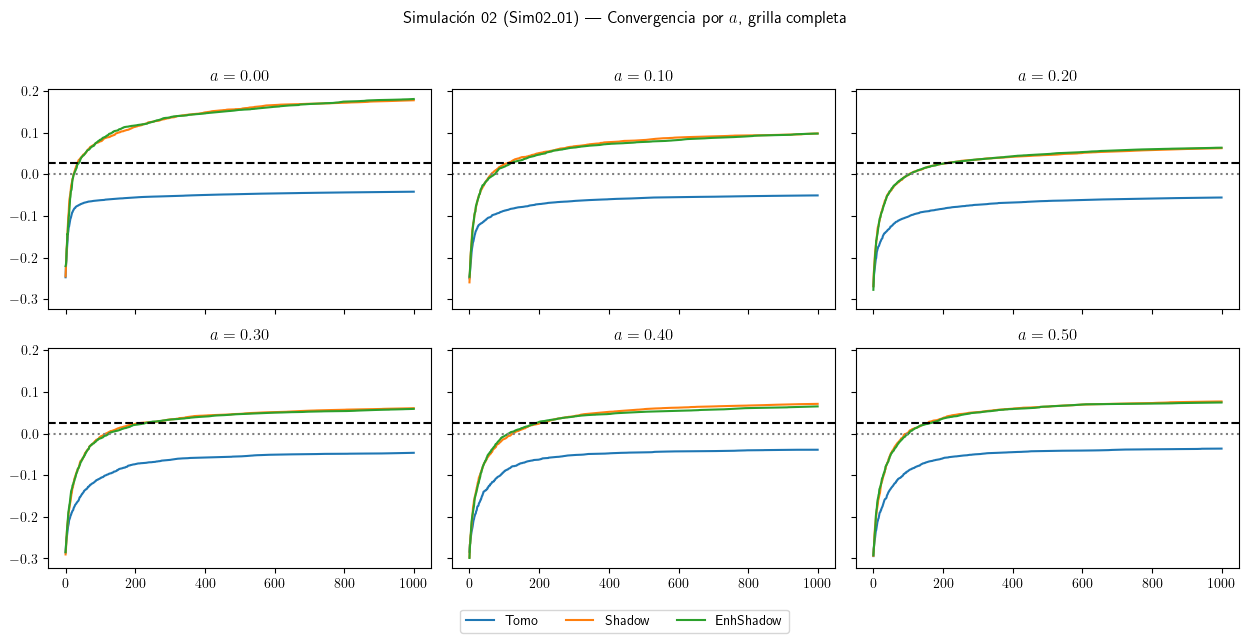

6

In [14]:
graficar_convergencia_grid("Sim02_01", "Simulacion_02", "a", "a",
                            r"Simulación 02 (Sim02\_01) --- Convergencia por $a$, grilla completa",
                            "Simulacion_02/Sim02_01_conv.pdf")

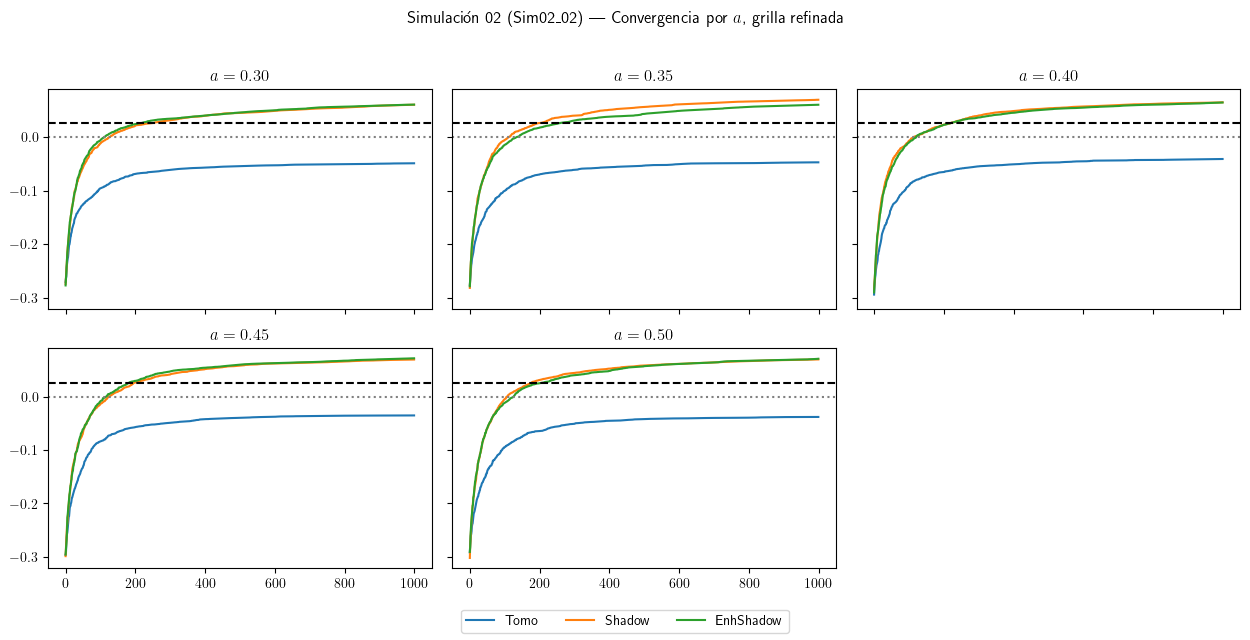

5

In [15]:
graficar_convergencia_grid("Sim02_02", "Simulacion_02", "a", "a",
                            r"Simulación 02 (Sim02\_02) --- Convergencia por $a$, grilla refinada",
                            "Simulacion_02/Sim02_02_conv.pdf")

# Simulación 03

**Carpeta de datos:** `Simulacion_03`

**Parámetros:**

| Parámetro | Valor |
|---|---|
| Estado (tres fuentes) | Werner, $p\,\lvert\psi^-\rangle\langle\psi^-\rvert+(1-p)\,\mathbb{I}_4/4$, mismo $p$ en las tres fuentes |
| $N$ (mediciones por sombra) | $10000$, sombra reentrenada en cada repetición |
| `max_rep` | 100 |
| `max_iter` | 1000 |
| `gains` | `[3, 0, 0.1, 0.602, 0.101]` |
| Optimizador | CSPSA (`minimize=False`, maximización) |

**Descripción:** tercer escenario de la serie, en el que las tres
fuentes de la red triangular distribuyen el mismo estado de Werner,
variando el parámetro de pureza $p$ entre el estado maximamente mixto
($p=0$) y el estado singlete puro ($p=1$). Se corre en dos grillas
distintas de $p$, identificadas como Sim03_01 y Sim03_02, para explorar
primero el rango completo y luego refinar la zona cercana al estado
puro.

**Sim03_01, grilla completa:** $p \in \{0.0,\ 0.1,\ 0.2,\ 0.3,\ 0.4,\ 0.5,\ 0.6,\ 0.7,\ 0.8,\ 0.9,\ 1.0\}$,
paso $0.1$.

**Sim03_02, grilla refinada:** $p \in \{0.90,\ 0.91,\ \dots,\ 1.00\}$,
paso $0.01$, restringida a la región $[0.9, 1.0]$.

**Archivos generados:** `Simulacion_03/Sim03_01_p{valor}.npz` y
`Simulacion_03/Sim03_02_p{valor}.npz`, uno por cada valor de $p$ en cada
grilla, cada uno con el arreglo crudo de cada nivel (`Out1`, `Out2`,
`Out3`) junto con `mean`, `median`, `q1` y `q3` por iteración para cada
uno.

In [ ]:
def run_werner_grid(valores_p, prefijo, carpeta="Simulacion_03",
                     N_rep=100, max_iter=1000, N_shadow=10000):
    """
    Corre run_simulation una vez por cada valor de p en 'valores_p',
    construyendo el estado de Werner con ese parametro en las tres
    fuentes, y guardando cada resultado como carpeta/prefijo_p{valor}.npz.
    """
    resultados = {}
    for p in valores_p:
        print(f"=== {prefijo}, p = {p:.2f} ===")
        Rho_wer = build_network_state(*3 * [werner_state(p)])
        nombre_archivo = f"{prefijo}_p{p:.2f}.npz"

        Out1, Out2, Out3 = run_simulation(
            Rho_wer,
            N_rep=N_rep,
            max_iter=max_iter,
            N_shadow=N_shadow,
            nombre_archivo=nombre_archivo,
            carpeta=carpeta
        )
        resultados[p] = (Out1, Out2, Out3)

    return resultados


In [16]:
valores_sim03_01 = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
valores_sim03_02 = [0.90, 0.91, 0.92, 0.93, 0.94, 0.95, 0.96, 0.97, 0.98, 0.99, 1.00]

#resultados_sim03_01 = run_werner_grid(valores_sim03_01, "Sim03_01", carpeta="Simulacion_03")
#resultados_sim03_02 = run_werner_grid(valores_sim03_02, "Sim03_02", carpeta="Simulacion_03")

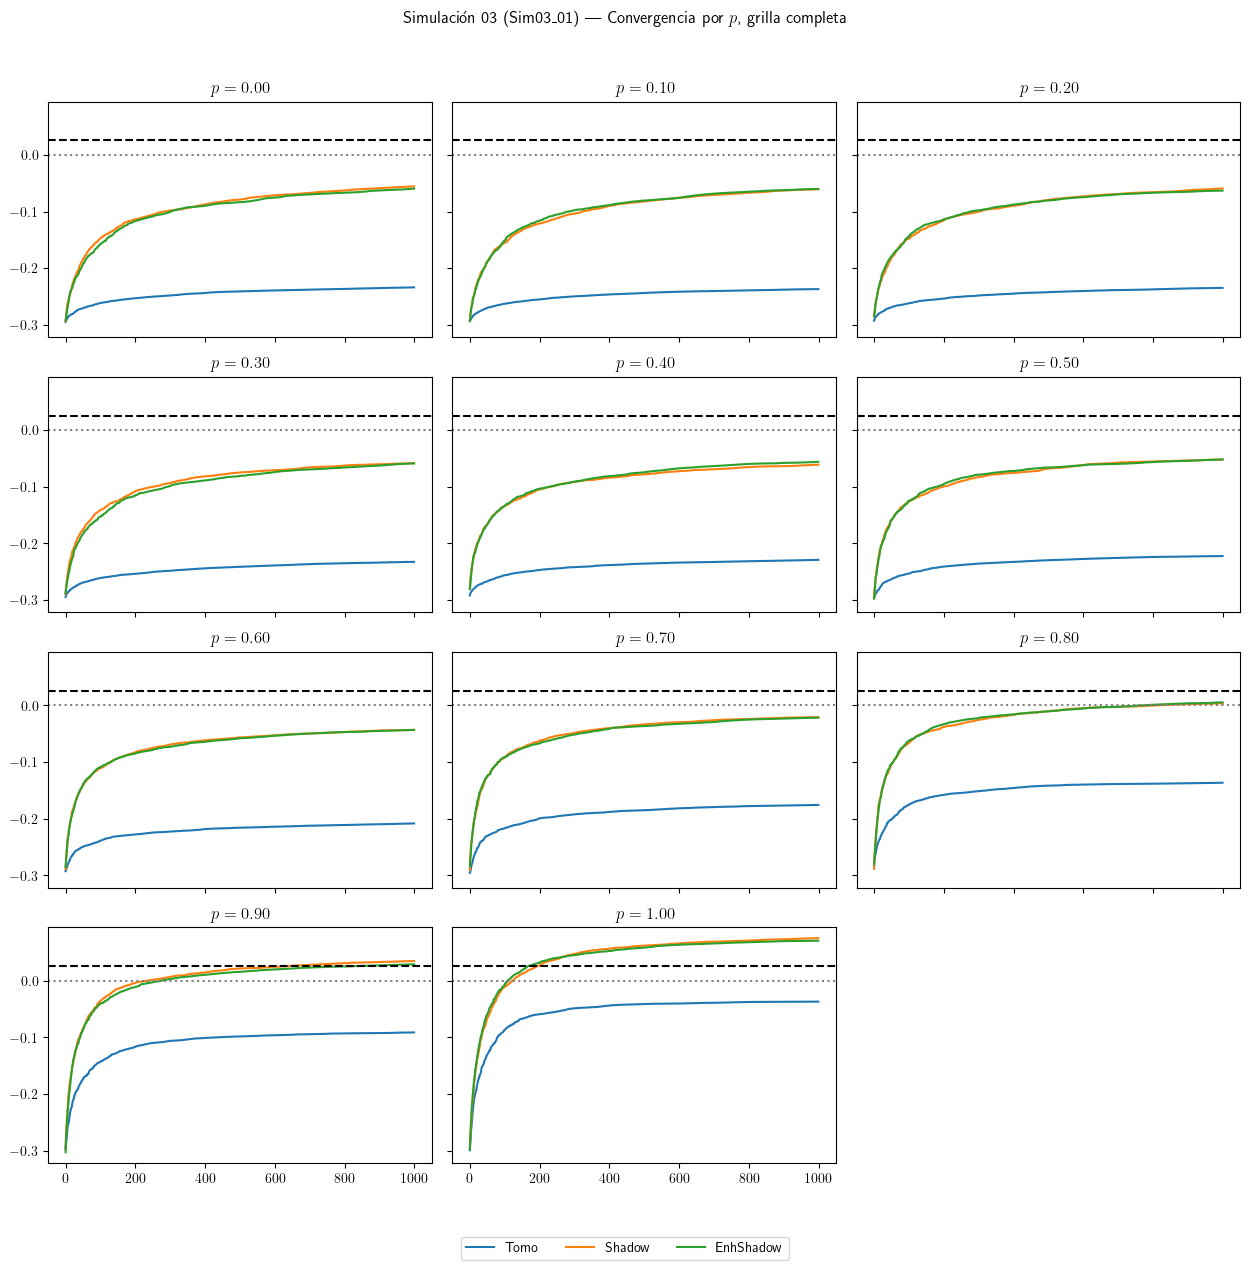

11

In [17]:
graficar_convergencia_grid("Sim03_01", "Simulacion_03", "p", "p",
                            r"Simulación 03 (Sim03\_01) --- Convergencia por $p$, grilla completa",
                            "Simulacion_03/Sim03_01_conv.pdf")

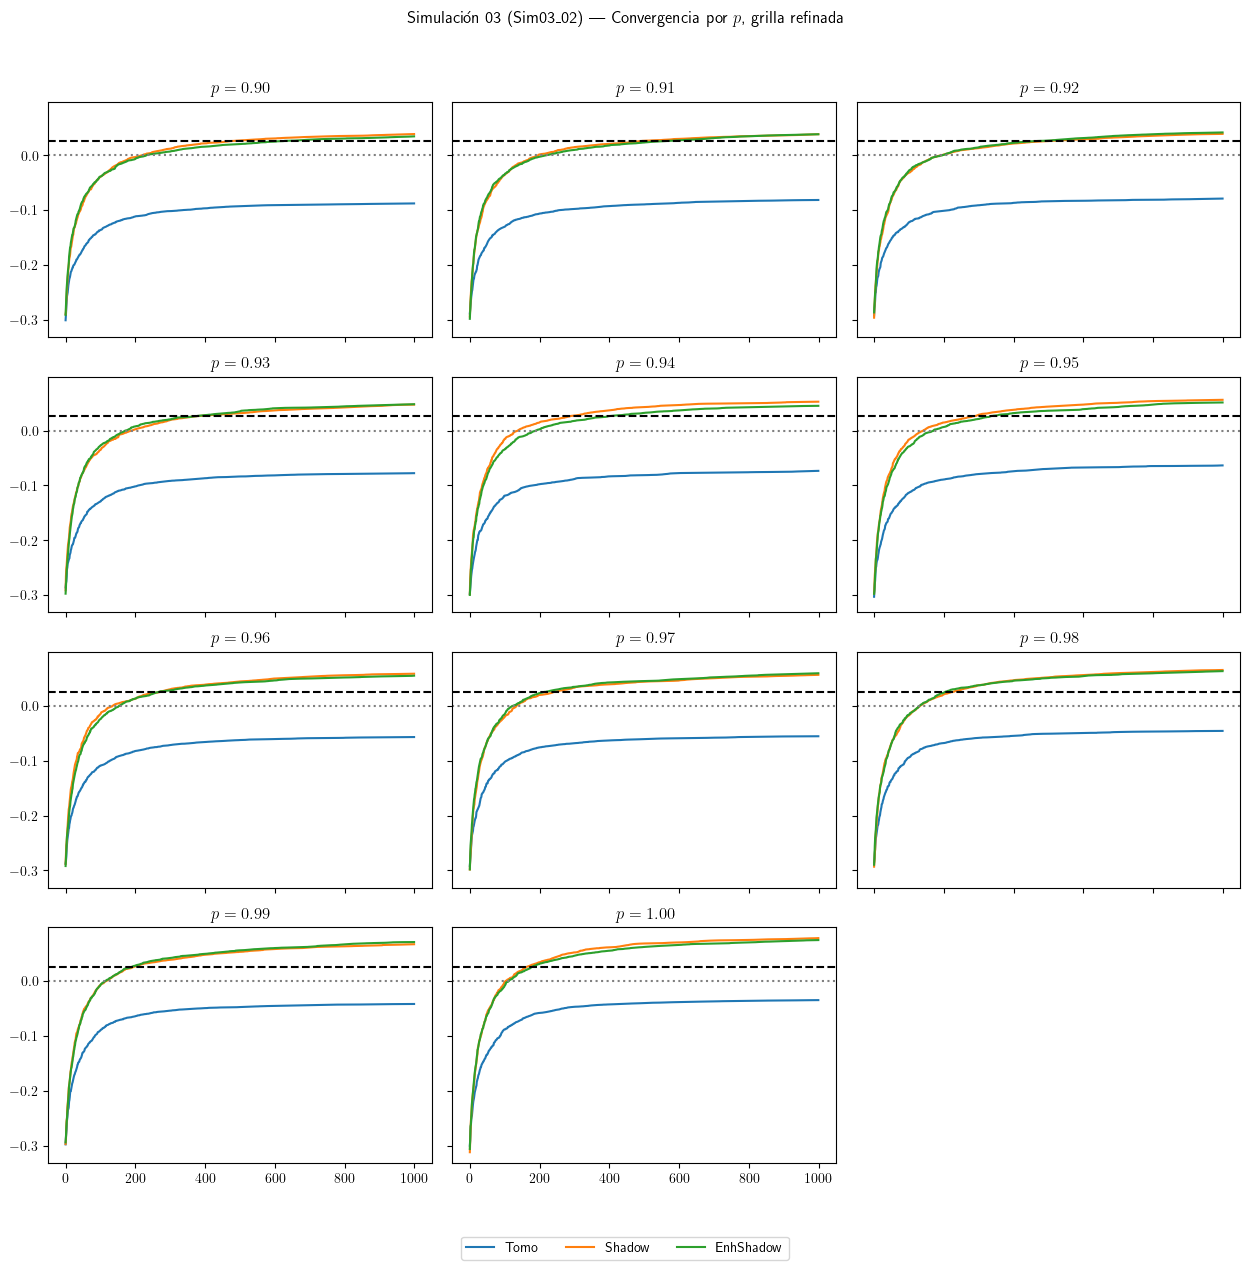

11

In [18]:
graficar_convergencia_grid("Sim03_02", "Simulacion_03", "p", "p",
                            r"Simulación 03 (Sim03\_02) --- Convergencia por $p$, grilla refinada",
                            "Simulacion_03/Sim03_02_conv.pdf")

valores_sim03_02 = [0.90, 0.91, 0.92, 0.93, 0.94, 0.95, 0.96, 0.97, 0.98, 0.99, 1.00]

resultados_sim03_02 = run_werner_grid(valores_sim03_02, "Sim03_02", carpeta="Simulacion_03")